In [2]:
import json
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from collections import Counter, defaultdict
from pathlib import Path
from sklearn.metrics import roc_auc_score

import csv
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import roc_auc_score

In [3]:
PT_DIR = Path(
    "logs/hidden_states/math/(specific system prompt+no suffix)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct"
)
PT_DIR_ADD = Path(
    "logs/hidden_states/math/(add_v2)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct"
)
JSONL_PATH = Path(
    "logs/math/sharded-at0-ut0/(specific system prompt+no suffix)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl"
)
JSONL_PATH_ADD = Path(
    "logs/math/sharded-at0-ut0/(add_v2)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl"
)

PT_SOURCES    = [PT_DIR, PT_DIR_ADD]
JSONL_SOURCES = [JSONL_PATH, JSONL_PATH_ADD]
LAYERS         = [12, 16, 20, 24, 28]

In [4]:
def turn_sort_key(label: str):
    if not label.startswith("turn_"):
        return (1, label)
    try:
        return (0, int(label.split("_", 1)[1]))
    except ValueError:
        return (0, label)

def turn_index(label: str) -> int:
    return int(label.split("_", 1)[1])

In [5]:
# ── Step 1: 加载 .pt 文件 ─────────────────────────────────────────────────────
print("=" * 60)
print("Step 1: Loading .pt files")
print("=" * 60)

conv_records = {}
stats = dict(no_score=0, no_goal=0, too_few_turns=0, duplicate=0)
seen_conv_ids = set()

for pt_dir in PT_SOURCES:
    pt_files = sorted(pt_dir.glob("*.pt"))
    print(f"  {pt_dir.name}: {len(pt_files)} files")
    for pt_file in pt_files:
        conv_id = pt_file.stem

        if conv_id in seen_conv_ids:
            stats["duplicate"] += 1
            continue
        seen_conv_ids.add(conv_id)

        # if conv_id not in score_map:
        #     stats["no_score"] += 1
        #     continue

        data        = torch.load(pt_file, map_location="cpu", weights_only=False)
        hs_list     = data.get("hidden_states", [])
        hs_by_label = {entry["label"]: entry["hidden_states"] for entry in hs_list}

        if "goal" not in hs_by_label:
            stats["no_goal"] += 1
            continue

        turn_labels = sorted(
            [k for k in hs_by_label if k.startswith("turn_")],
            key=turn_sort_key,
        )
        if len(turn_labels) < 3:
            stats["too_few_turns"] += 1
            continue

        goal_hs    = [hs_by_label["goal"][i].numpy() for i in range(len(LAYERS))]
        turns_data = {
            tlabel: [hs_by_label[tlabel][i].numpy() for i in range(len(LAYERS))]
            for tlabel in turn_labels
        }
        max_turn = max(turn_index(tl) for tl in turn_labels)

        conv_records[conv_id] = {
            # "score"   : score_map[conv_id],
            "goal_hs" : goal_hs,
            "turns_hs"   : turns_data,
            "max_turn": max_turn,
        }

print(f"\n  Loaded conv records: {len(conv_records)}")
for k, v in stats.items():
    if v:
        print(f"  Skipped ({k:16s}): {v}")

Step 1: Loading .pt files
  (specific system prompt+no suffix)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct: 103 files
  (add_v2)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct: 241 files

  Loaded conv records: 320
  Skipped (too_few_turns   ): 24


In [6]:
# ── Step 2: 读取 JSONL ────────────────────────────────────────────────────────
print("=" * 60)
print("Step 2: Reading scores")
print("=" * 60)

score_map = {}
for jsonl_path in JSONL_SOURCES:
    loaded = 0
    with open(jsonl_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec     = json.loads(line)
            trace = rec.get('trace', [])
            
            # ---------- Conversational behavior statistics ----------
            response_types = []
            answer_attempts = []
            num_turns = 0          # Number of user turns
            num_assistant = 0
            for entry in trace:
                role = entry.get('role', '')
                if role == 'user':
                    num_turns += 1
                elif role == 'assistant':
                    num_assistant += 1
                elif role == 'log':
                    content = entry.get('content', {})
                    if isinstance(content, dict):
                        if content.get('type') == 'system-verification':
                            rt = content.get('response', {}).get('response_type', 'unknown')
                            response_types.append(rt)
                        elif content.get('type') == 'answer-evaluation':
                            answer_attempts.append({
                                'exact_answer': content.get('exact_answer'),
                                'is_correct':   content.get('is_correct'),
                                'score':        content.get('score', 0.0),
                            })

            rt_counter = Counter(response_types)
            
            conv_id = rec.get("conv_id")
            score   = rec.get("score")
            
            # TODO
            if score is None:
                score = 0.0
            
            if conv_id is None or score is None:
                continue
            
            score_map[conv_id] = int(float(score))
            
            loaded += 1
            
    print(f"  Loaded {loaded:4d} records from {jsonl_path.name}")

n_correct   = sum(v == 1 for v in score_map.values())
n_incorrect = sum(v == 0 for v in score_map.values())
print(f"  Total: {len(score_map)}  (correct={n_correct}, incorrect={n_incorrect})\n")

Step 2: Reading scores
  Loaded  103 records from (specific system prompt+no suffix)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl
  Loaded  241 records from (add_v2)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl
  Total: 344  (correct=168, incorrect=176)



In [7]:
# ============================================================
# Cell A — imports & config  (add after your existing imports)
# ============================================================
 
from collections import defaultdict
from sklearn.decomposition import PCA
import matplotlib.gridspec as gridspec
 
ALL_TYPES = ["answer_attempt", "clarification", "refusal",
             "hedging", "interrogation", "discussion", "missing"]
 
TYPE_COLORS = {
    "answer_attempt": "#2196F3",
    "clarification" : "#4CAF50",
    "refusal"       : "#F44336",
    "hedging"       : "#FF9800",
    "interrogation" : "#9C27B0",
    "discussion"    : "#00BCD4",
    "missing"       : "#9E9E9E",
}



In [8]:
# ============================================================
# Cell B — parse response_type from JSONL into per-turn metadata
# ============================================================
# Run AFTER your existing Step 2 (score loading)
# Adds turn_rt to score_map entries
 
turn_rt_map = {}   # conv_id → {turn_idx (int): response_type (str)}
 
for jsonl_path in JSONL_SOURCES:
    with open(jsonl_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec     = json.loads(line)
            conv_id = rec.get("conv_id")
            if conv_id is None:
                continue
 
            trace = rec.get("trace", [])
            turn_rt   = {}
            user_turn_idx = 0
 
            for entry in trace:
                role = entry.get("role", "")
                if role == "user":
                    user_turn_idx += 1
                elif role == "log":
                    content = entry.get("content", {})
                    if isinstance(content, dict) and content.get("type") == "system-verification":
                        rt = content.get("response", {}).get("response_type", "missing")
                        turn_rt[user_turn_idx] = rt
 
            turn_rt_map[conv_id] = turn_rt
 
print(f"Loaded turn_rt for {len(turn_rt_map)} conversations")
 
# Quick distribution check
from collections import Counter
all_rts = [rt for d in turn_rt_map.values() for rt in d.values()]
print("Response type distribution:", Counter(all_rts))

Loaded turn_rt for 344 conversations
Response type distribution: Counter({'answer_attempt': 738, 'discussion': 589, 'clarification': 290, 'interrogation': 38, 'hedge': 24, 'refuse': 20, 'missing': 8})


In [9]:
# ============================================================
# Cell C — build response-type mean vectors (= "role vectors")
# ============================================================
# Key design decision (mirrors Assistant Axis paper):
#   For each response_type, collect ALL hidden states where that
#   type was logged, then take the mean → one vector per type.
#   These vectors define the "response-type space".
 
# rt_accum[layer_idx][response_type] = [hs_array, ...]
rt_accum = {li: defaultdict(list) for li in range(len(LAYERS))}
 
for conv_id, rec in conv_records.items():
    turn_rt  = turn_rt_map.get(conv_id, {})
    turns_hs = rec["turns_hs"]
 
    for t_label, hs_per_layer in turns_hs.items():
        t_idx = turn_index(t_label)          # your existing helper
        rt    = turn_rt.get(t_idx, "missing")
        for li, hs in enumerate(hs_per_layer):
            rt_accum[li][rt].append(hs)
 
# Mean vector per type per layer
rt_vectors = {}   # layer_idx → {rt: ndarray}
print("\nSample counts per type (layer 20):")
for li in range(len(LAYERS)):
    rt_vectors[li] = {rt: np.mean(vecs, axis=0)
                      for rt, vecs in rt_accum[li].items()}
target_li = LAYERS.index(20)
print({rt: len(v) for rt, v in rt_accum[target_li].items()})


Sample counts per type (layer 20):
{'clarification': 280, 'interrogation': 38, 'discussion': 542, 'answer_attempt': 436, 'refuse': 19, 'hedge': 24, 'missing': 8}


In [10]:
# ============================================================
# Cell D — PCA on the 7 type-mean vectors (per layer)
# ============================================================
# Exactly follows the paper's §2.1.3:
#   1. Centre the type-mean matrix (subtract cross-type mean)
#   2. Run PCA  →  PC1 is the "Goal Commitment Axis"
 
layer_pca = {}   # layer_idx → {pca, coords, labels, var}
 
for li, layer in enumerate(LAYERS):
    present = [rt for rt in ALL_TYPES if rt in rt_vectors[li]]
    if len(present) < 2:
        continue
 
    mat = np.stack([rt_vectors[li][rt] for rt in present])   # (n_types, D)
    mat_centred = mat - mat.mean(axis=0, keepdims=True)       # centre
 
    n_comp = min(len(present), 3)
    pca    = PCA(n_components=n_comp)
    coords = pca.fit_transform(mat_centred)                   # (n_types, n_comp)
 
    layer_pca[li] = dict(pca=pca, coords=coords,
                          labels=present, var=pca.explained_variance_ratio_,
                          layer=layer, global_mean=mat.mean(axis=0))
 
print("Variance explained (PC1 / PC2 / PC3):")
for li, res in sorted(layer_pca.items()):
    var = res["var"]
    v3  = f"{var[2]*100:.1f}%" if len(var) > 2 else "—"
    print(f"  Layer {res['layer']:2d}:  {var[0]*100:.1f}%  {var[1]*100:.1f}%  {v3}")

Variance explained (PC1 / PC2 / PC3):
  Layer 12:  76.2%  18.9%  2.6%
  Layer 16:  77.7%  18.1%  2.6%
  Layer 20:  75.7%  19.9%  3.0%
  Layer 24:  77.0%  18.6%  3.2%
  Layer 28:  76.1%  19.3%  3.3%


In [11]:
# ============================================================
# Cell E — project every turn's HS onto PC1 ("drift monitoring")
# ============================================================
# Analogous to the paper's right panel of Fig 1: track position
# along the Goal-Commitment Axis across turns, split by outcome.
 
TARGET_LI = LAYERS.index(20)   # choose your most informative layer
 
res_pca   = layer_pca[TARGET_LI]
pca_model = res_pca["pca"]
g_mean    = res_pca["global_mean"]
 
scatter = []   # list of dicts: pc1, pc2, turn_idx, rt, score
 
for conv_id, rec in conv_records.items():
    score    = score_map.get(conv_id, 0)
    turn_rt  = turn_rt_map.get(conv_id, {})
    turns_hs = rec["turns_hs"]
 
    for t_label, hs_per_layer in turns_hs.items():
        t_idx = turn_index(t_label)
        hs    = hs_per_layer[TARGET_LI]
        proj  = pca_model.transform((hs - g_mean).reshape(1, -1))[0]
        rt    = turn_rt.get(t_idx, "missing")
        scatter.append(dict(pc1=proj[0],
                            pc2=proj[1] if len(proj) > 1 else 0.0,
                            turn=t_idx, rt=rt, score=score))
 
print(f"Projected {len(scatter)} turn points onto PC1 (layer {LAYERS[TARGET_LI]})")

Projected 1347 turn points onto PC1 (layer 20)


/tmp/ipykernel_2942552/2676534717.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


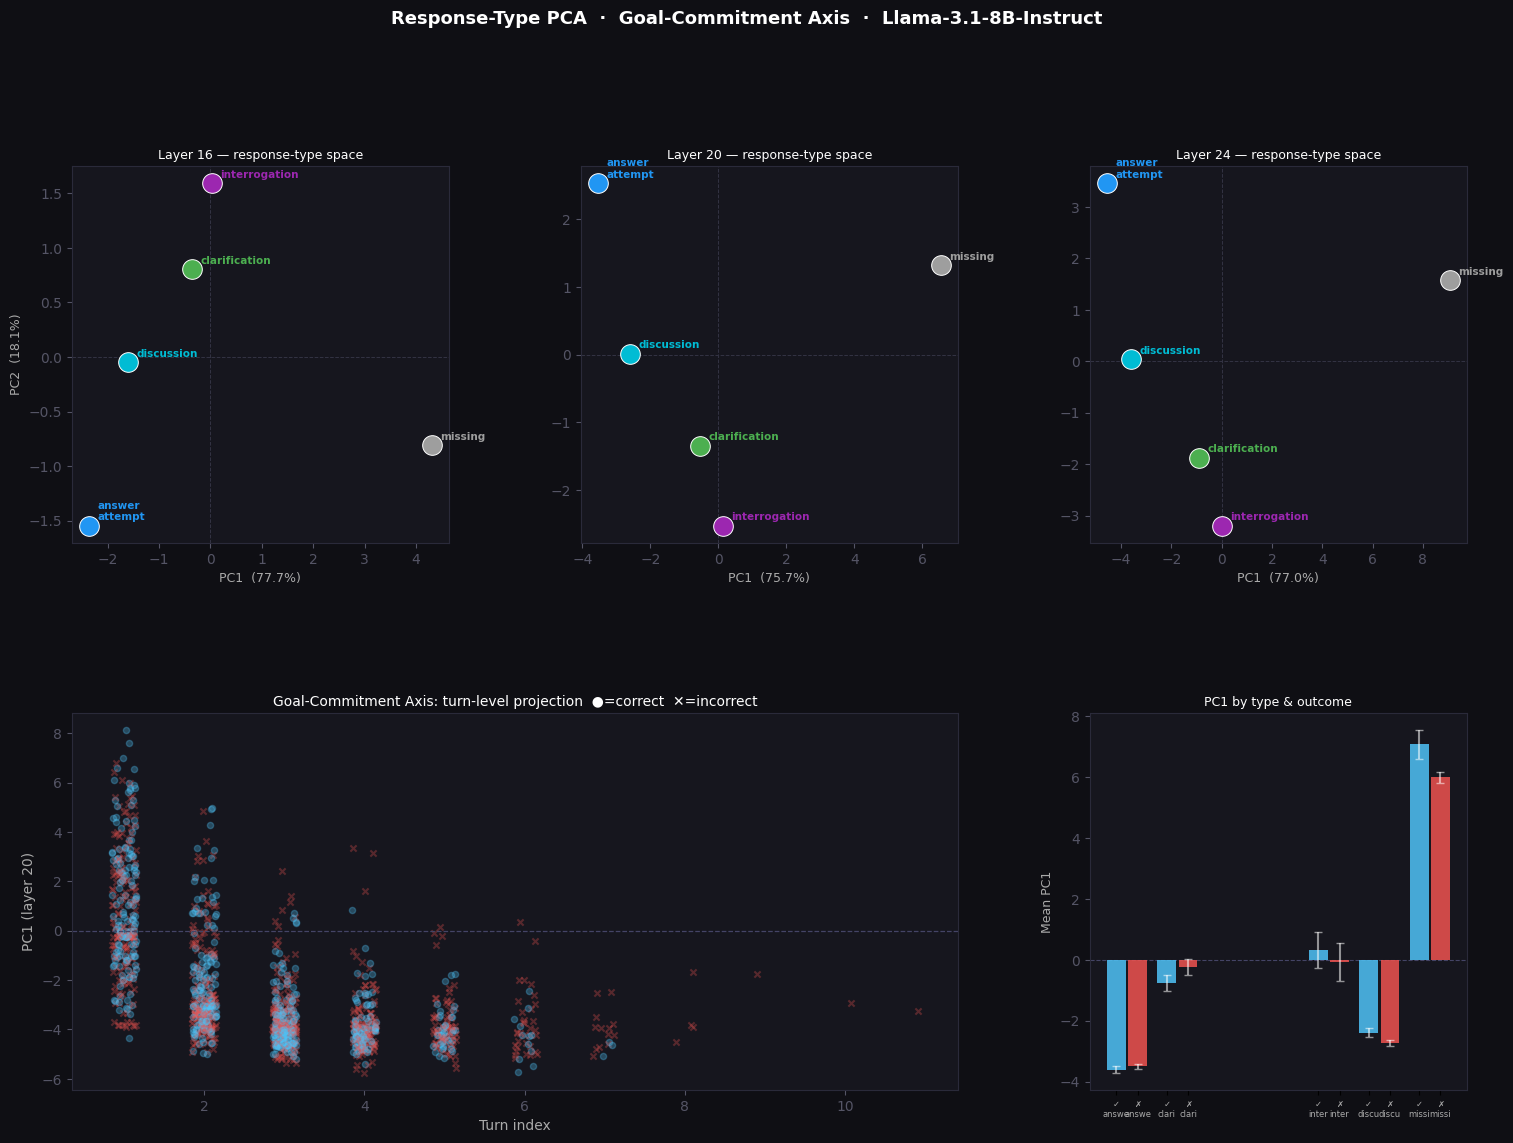

Saved → response_type_pca.png


In [12]:
# ============================================================
# Cell F — plots
# ============================================================
 
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor("#0f0f14")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
 
# ── Row 0: PC1/PC2 scatter of 7 type-mean vectors, for layers 12, 16, 20 ──
for col, li in enumerate([LAYERS.index(l) for l in [16, 20, 24]]):
    ax = fig.add_subplot(gs[0, col])
    ax.set_facecolor("#16161e")
    res = layer_pca.get(li)
    if res is None:
        continue
    for i, rt in enumerate(res["labels"]):
        c    = res["coords"][i]
        clr  = TYPE_COLORS.get(rt, "#aaaaaa")
        ax.scatter(c[0], c[1], color=clr, s=200, zorder=3,
                   edgecolors="white", linewidths=0.7)
        ax.annotate(rt.replace("_", "\n"), (c[0], c[1]),
                    xytext=(6, 4), textcoords="offset points",
                    fontsize=7.5, color=clr, fontweight="bold")
    ax.axhline(0, color="#334", lw=0.7, ls="--")
    ax.axvline(0, color="#334", lw=0.7, ls="--")
    ax.set_xlabel(f"PC1  ({res['var'][0]*100:.1f}%)", color="#aaaaaa", fontsize=9)
    if col == 0:
        ax.set_ylabel(f"PC2  ({res['var'][1]*100:.1f}%)", color="#aaaaaa", fontsize=9)
    ax.set_title(f"Layer {res['layer']} — response-type space", color="white", fontsize=9, pad=5)
    ax.tick_params(colors="#555566")
    for sp in ax.spines.values():
        sp.set_edgecolor("#2a2a3a")
 
# ── Row 1 left+mid: PC1 vs turn, coloured by correctness ──────────────────
ax_b = fig.add_subplot(gs[1, :2])
ax_b.set_facecolor("#16161e")
rng = np.random.default_rng(42)
for pt in scatter:
    jitter = rng.uniform(-0.15, 0.15)
    mk  = "o" if pt["score"] == 1 else "x"
    clr = "#4fc3f7" if pt["score"] == 1 else "#ef5350"
    ax_b.scatter(pt["turn"] + jitter, pt["pc1"],
                 color=clr, alpha=0.3, s=20, marker=mk, zorder=2)
ax_b.axhline(0, color="#446", lw=0.9, ls="--")
ax_b.set_xlabel("Turn index", color="#aaaaaa", fontsize=10)
ax_b.set_ylabel(f"PC1 (layer {LAYERS[TARGET_LI]})", color="#aaaaaa", fontsize=10)
ax_b.set_title("Goal-Commitment Axis: turn-level projection  ●=correct  ✕=incorrect",
               color="white", fontsize=10, pad=5)
ax_b.tick_params(colors="#555566")
for sp in ax_b.spines.values():
    sp.set_edgecolor("#2a2a3a")
 
# ── Row 1 right: mean PC1 per type, split by score ────────────────────────
ax_c = fig.add_subplot(gs[1, 2])
ax_c.set_facecolor("#16161e")
 
rt_pc1 = {s: defaultdict(list) for s in [0, 1]}
for pt in scatter:
    rt_pc1[pt["score"]][pt["rt"]].append(pt["pc1"])
 
xpos = 0; xtick_pos = []; xtick_lbl = []
for rt in ALL_TYPES:
    for score, clr in [(1, "#4fc3f7"), (0, "#ef5350")]:
        vals = rt_pc1[score][rt]
        if not vals:
            xpos += 0.4; continue
        mu = np.mean(vals); se = np.std(vals) / np.sqrt(len(vals))
        ax_c.bar(xpos, mu, 0.35, color=clr, alpha=0.85,
                 yerr=se, error_kw=dict(ecolor="#ffffff88", capsize=3), zorder=3)
        xtick_pos.append(xpos)
        xtick_lbl.append(f"{'✓' if score==1 else '✗'}\n{rt[:5]}")
        xpos += 0.4
    xpos += 0.15
 
ax_c.set_xticks(xtick_pos); ax_c.set_xticklabels(xtick_lbl, fontsize=6, color="#aaaaaa")
ax_c.set_ylabel("Mean PC1", color="#aaaaaa", fontsize=9)
ax_c.set_title("PC1 by type & outcome", color="white", fontsize=9, pad=5)
ax_c.axhline(0, color="#446", lw=0.8, ls="--")
ax_c.tick_params(axis="y", colors="#555566")
for sp in ax_c.spines.values():
    sp.set_edgecolor("#2a2a3a")
 
fig.suptitle("Response-Type PCA  ·  Goal-Commitment Axis  ·  Llama-3.1-8B-Instruct",
             color="white", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("response_type_pca.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → response_type_pca.png")

Built 707 (conv, turn) curvature records

Top 10 bigrams (rt[t] → rt[t+1]):
  discussion           → discussion            n= 237  correct=37%
  answer_attempt       → answer_attempt        n= 211  correct=29%
  discussion           → answer_attempt        n= 137  correct=33%
  clarification        → clarification         n=  90  correct=67%
  clarification        → discussion            n=  84  correct=43%
  clarification        → answer_attempt        n=  53  correct=47%
  discussion           → clarification         n=  51  correct=51%
  answer_attempt       → discussion            n=  42  correct=26%
  interrogation        → clarification         n=  15  correct=53%
  clarification        → interrogation         n=  12  correct=33%


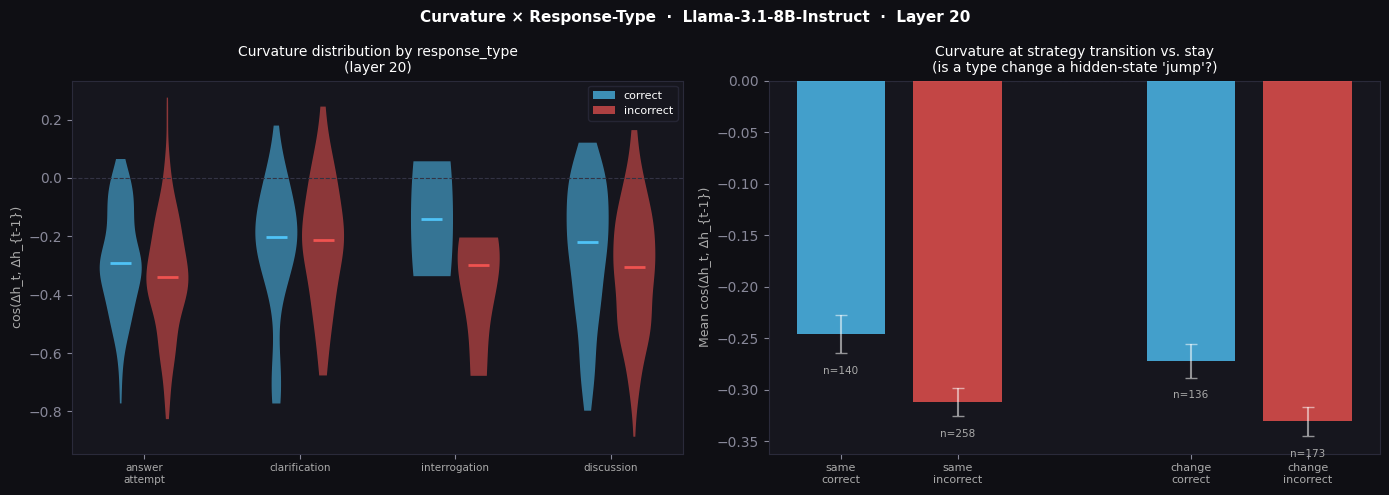

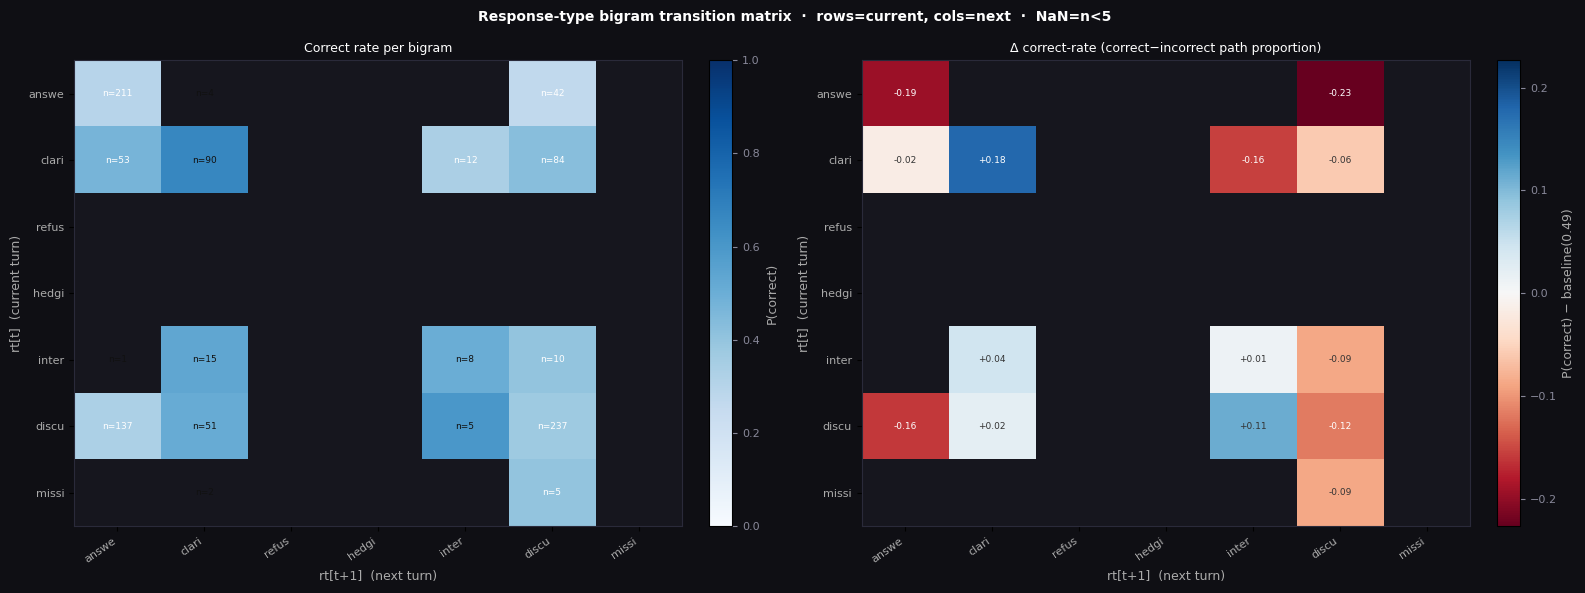

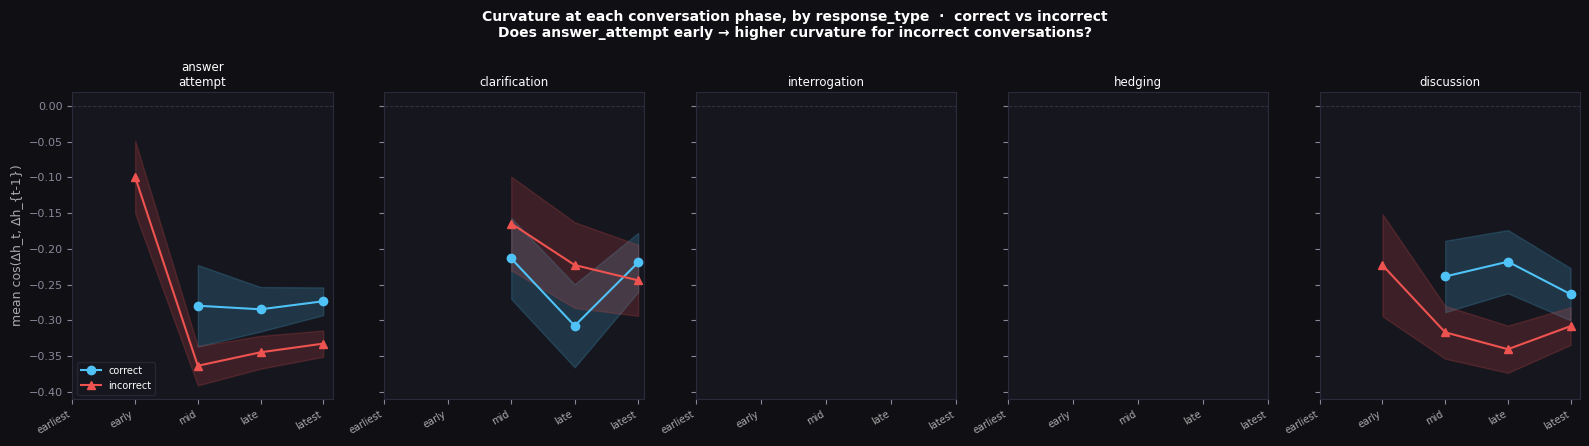


── Mean curvature by response_type & outcome (layer 20) ──
rt                      n_correct    mean_c   n_incorr    mean_i    Δ (c−i)
  answer_attempt              120   -0.2765        234   -0.3360    +0.0595
  clarification                57   -0.2403         36   -0.2191    -0.0212
  refusal                       0       nan          0       nan       +nan
  hedging                       0       nan          0       nan       +nan
  interrogation                 2   -0.1398          4   -0.3699    +0.2301
  discussion                   89   -0.2492        155   -0.3134    +0.0642
  missing                       0       nan          0       nan       +nan


In [36]:
# ============================================================
# Strategy Path Analysis
# Connects response_type sequences to cos(Δh) curvature signal
#
# Assumes already in memory (from your existing cells):
#   conv_records   : {conv_id: {turns_hs, max_turn, ...}}
#   score_map      : {conv_id: 0/1}
#   turn_rt_map    : {conv_id: {turn_idx: response_type}}
#   LAYERS         : [12, 16, 20, 24, 28]
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict, Counter
from itertools import pairwise   # Python 3.10+; use zip(lst, lst[1:]) if older

# If Python < 3.10, replace pairwise with:
# def pairwise(iterable):
#     a, b = iter(iterable), iter(iterable)
#     next(b, None)
#     return zip(a, b)

ALL_TYPES = ["answer_attempt", "clarification", "refusal",
             "hedging", "interrogation", "discussion", "missing"]

FOCUS_LAYER_IDX = 2   # layer 20 in LAYERS=[12,16,20,24,28]

# ── Helper: compute cosine similarity between two vectors ─────────────────────
def cosine(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na < 1e-9 or nb < 1e-9:
        return np.nan
    return float(np.dot(a, b) / (na * nb))

# ============================================================
# STEP A: Build per-conversation curvature sequences
#         and align them with response_type sequences
# ============================================================
# For each conv, for the focus layer, compute:
#   delta_t   = h_t - h_{t-1}
#   curve_t   = cos(delta_t, delta_{t-1})   (defined from turn 3 onward)
# and pair each curve value with the response_type at turn t.

records = []   # list of dicts, one per (conv_id, turn)

for conv_id, rec in conv_records.items():
    score    = score_map.get(conv_id)
    if score is None:
        continue
    turn_rt  = turn_rt_map.get(conv_id, {})
    turns_hs = rec["turns_hs"]   # {label: [hs_layer0, ...]}

    # Sort turn labels numerically
    turn_labels = sorted(
        [k for k in turns_hs if k.startswith("turn_")],
        key=lambda l: int(l.split("_")[1])
    )
    if len(turn_labels) < 3:
        continue

    # Extract hidden states at focus layer in turn order
    idxs  = [int(l.split("_")[1]) for l in turn_labels]
    hs_seq = [turns_hs[l][FOCUS_LAYER_IDX] for l in turn_labels]

    # Compute delta vectors
    deltas = [hs_seq[i] - hs_seq[i-1] for i in range(1, len(hs_seq))]

    # Compute curvature = cos(delta_t, delta_{t-1}), from position 2 onward
    for i in range(1, len(deltas)):
        t_idx = idxs[i + 1]         # turn index at which delta[i] ends
        rt    = turn_rt.get(t_idx, "missing")
        curve = cosine(deltas[i], deltas[i-1])
        records.append({
            "conv_id"  : conv_id,
            "turn"     : t_idx,
            "score"    : score,
            "rt"       : rt,
            "curvature": curve,
            "total_turns": rec["max_turn"],
        })

print(f"Built {len(records)} (conv, turn) curvature records")

# ── STEP B: Build response_type transition sequences per conv ─────────────────
# For each conv, the ordered sequence of rt labels.
# We'll compute bigram (rt[t], rt[t+1]) → {n_correct, n_total}

bigram_stats = defaultdict(lambda: {"correct": 0, "total": 0})
path_store   = []   # (conv_id, rt_sequence, score)

for conv_id, rec in conv_records.items():
    score   = score_map.get(conv_id)
    if score is None:
        continue
    turn_rt = turn_rt_map.get(conv_id, {})
    turn_labels = sorted(
        [k for k in rec["turns_hs"] if k.startswith("turn_")],
        key=lambda l: int(l.split("_")[1])
    )
    if len(turn_labels) < 3:
        continue

    idxs   = [int(l.split("_")[1]) for l in turn_labels]
    rt_seq = [turn_rt.get(i, "missing") for i in idxs]
    path_store.append((conv_id, rt_seq, score))

    for a, b in zip(rt_seq, rt_seq[1:]):
        bigram_stats[(a, b)]["total"]   += 1
        bigram_stats[(a, b)]["correct"] += score

# Sort bigrams by frequency
sorted_bigrams = sorted(bigram_stats.items(), key=lambda x: -x[1]["total"])
print(f"\nTop 10 bigrams (rt[t] → rt[t+1]):")
for (a, b), s in sorted_bigrams[:10]:
    pct = 100 * s["correct"] / s["total"] if s["total"] else 0
    print(f"  {a:20s} → {b:20s}  n={s['total']:4d}  correct={pct:.0f}%")

# ============================================================
# PLOT 1: Curvature distribution by response_type (box/violin)
# ============================================================
# Shows: does the hidden-space geometry differ between strategies?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0f0f14")
for ax in axes:
    ax.set_facecolor("#16161e")
    ax.tick_params(colors="#888899")
    for sp in ax.spines.values():
        sp.set_edgecolor("#2a2a3a")

# --- left: curvature per rt, violin ---
ax = axes[0]
rt_curve_correct   = defaultdict(list)
rt_curve_incorrect = defaultdict(list)
for r in records:
    if np.isnan(r["curvature"]):
        continue
    d = rt_curve_correct if r["score"] == 1 else rt_curve_incorrect
    d[r["rt"]].append(r["curvature"])

present_types = [rt for rt in ALL_TYPES
                 if rt_curve_correct[rt] or rt_curve_incorrect[rt]]

positions = np.arange(len(present_types))
w = 0.3

for offset, d, clr, lbl in [
    (-w/2, rt_curve_correct,   "#4fc3f7", "correct"),
    ( w/2, rt_curve_incorrect, "#ef5350", "incorrect"),
]:
    vals = [d[rt] for rt in present_types]
    vp = ax.violinplot(vals, positions=positions + offset,
                       widths=w*0.9, showmedians=True,
                       showextrema=False)
    for body in vp["bodies"]:
        body.set_facecolor(clr)
        body.set_alpha(0.55)
    vp["cmedians"].set_color(clr)
    vp["cmedians"].set_linewidth(2)

ax.set_xticks(positions)
ax.set_xticklabels([rt.replace("_", "\n") for rt in present_types],
                   fontsize=7.5, color="#aaaaaa")
ax.set_ylabel("cos(Δh_t, Δh_{t-1})", color="#aaaaaa", fontsize=9)
ax.set_title(f"Curvature distribution by response_type\n(layer {LAYERS[FOCUS_LAYER_IDX]})",
             color="white", fontsize=10, pad=6)
ax.axhline(0, color="#334", lw=0.8, ls="--")

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="#4fc3f7", alpha=0.7, label="correct"),
                   Patch(facecolor="#ef5350", alpha=0.7, label="incorrect")],
          facecolor="#16161e", edgecolor="#2a2a3a", labelcolor="white", fontsize=8)

# --- right: curvature at rt TRANSITIONS (bigrams) ---
ax = axes[1]
# For each (conv, turn) record, look up whether this turn was a *type change*
# relative to the previous turn

# Build per-conv turn-to-rt lookup
conv_rt_seq = {cid: {int(l.split("_")[1]): turn_rt_map.get(cid, {}).get(int(l.split("_")[1]), "missing")
                     for l in conv_records[cid]["turns_hs"]
                     if l.startswith("turn_")}
               for cid in conv_records}

transition_curves = {"same_type": {"correct": [], "incorrect": []},
                     "type_change": {"correct": [], "incorrect": []}}

for r in records:
    cid = r["conv_id"]
    t   = r["turn"]
    rt_now  = r["rt"]
    rt_prev = conv_rt_seq.get(cid, {}).get(t - 1, None)
    if rt_prev is None or np.isnan(r["curvature"]):
        continue
    key = "same_type" if rt_now == rt_prev else "type_change"
    sub = "correct" if r["score"] == 1 else "incorrect"
    transition_curves[key][sub].append(r["curvature"])

positions = [0, 0.5, 1.5, 2.0]
labels    = ["same\ncorrect", "same\nincorrect",
             "change\ncorrect", "change\nincorrect"]
colors    = ["#4fc3f7", "#ef5350", "#4fc3f7", "#ef5350"]
alphas    = [0.8, 0.8, 0.8, 0.8]
data_keys = [("same_type","correct"),  ("same_type","incorrect"),
             ("type_change","correct"), ("type_change","incorrect")]

for pos, lbl, clr, dk in zip(positions, labels, colors, data_keys):
    vals = transition_curves[dk[0]][dk[1]]
    if not vals:
        continue
    mu = np.mean(vals); se = np.std(vals) / np.sqrt(len(vals))
    ax.bar(pos, mu, 0.38, color=clr, alpha=0.8,
           yerr=se, error_kw=dict(ecolor="#ffffff88", capsize=4), zorder=3)
    ax.text(pos, mu + (se + 0.02) * np.sign(mu),
            f"n={len(vals)}", ha="center", fontsize=7.5, color="#aaaaaa")

ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=8, color="#aaaaaa")
ax.set_ylabel("Mean cos(Δh_t, Δh_{t-1})", color="#aaaaaa", fontsize=9)
ax.set_title("Curvature at strategy transition vs. stay\n(is a type change a hidden-state 'jump'?)",
             color="white", fontsize=10, pad=6)
ax.axhline(0, color="#334", lw=0.8, ls="--")

fig.suptitle("Curvature × Response-Type  ·  Llama-3.1-8B-Instruct  ·  Layer 20",
             color="white", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("plot1_curvature_x_rt.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

# ============================================================
# PLOT 2: Bigram transition matrix → outcome rate
# ============================================================
# Heatmap: rows = rt[t], cols = rt[t+1], cell = correct rate
# Only show transitions with n >= MIN_N

MIN_N = 5
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#0f0f14")

for ax_idx, (score_label, score_val, cmap) in enumerate([
    ("Correct rate per bigram", None, "Blues"),
    ("Δ correct-rate (correct−incorrect path proportion)", None, "RdBu"),
]):
    ax = axes[ax_idx]
    ax.set_facecolor("#16161e")

    # Build matrix
    mat   = np.full((len(ALL_TYPES), len(ALL_TYPES)), np.nan)
    count = np.zeros((len(ALL_TYPES), len(ALL_TYPES)), dtype=int)
    rt2i  = {rt: i for i, rt in enumerate(ALL_TYPES)}

    for (a, b), s in bigram_stats.items():
        if a not in rt2i or b not in rt2i:
            continue
        i, j = rt2i[a], rt2i[b]
        count[i, j] = s["total"]
        if s["total"] >= MIN_N:
            mat[i, j] = s["correct"] / s["total"]

    if ax_idx == 0:
        im = ax.imshow(mat, cmap=cmap, vmin=0, vmax=1, aspect="auto")
        cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cb.ax.tick_params(colors="#888899", labelsize=8)
        cb.set_label("P(correct)", color="#aaaaaa", fontsize=9)

        # Annotate cells with n
        for i in range(len(ALL_TYPES)):
            for j in range(len(ALL_TYPES)):
                n = count[i, j]
                if n > 0:
                    ax.text(j, i, f"n={n}", ha="center", va="center",
                            fontsize=6.5, color="white" if not np.isnan(mat[i,j]) and mat[i,j] < 0.5 else "#111")
    else:
        # For ax_idx == 1: show how much each path pattern deviates from baseline
        baseline = sum(score_map.values()) / len(score_map)
        diff_mat = np.where(np.isnan(mat), np.nan, mat - baseline)
        vext = np.nanmax(np.abs(diff_mat)) or 0.3
        im = ax.imshow(diff_mat, cmap="RdBu", vmin=-vext, vmax=vext, aspect="auto")
        cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cb.ax.tick_params(colors="#888899", labelsize=8)
        cb.set_label(f"P(correct) − baseline({baseline:.2f})", color="#aaaaaa", fontsize=9)
        for i in range(len(ALL_TYPES)):
            for j in range(len(ALL_TYPES)):
                if not np.isnan(diff_mat[i, j]):
                    val = diff_mat[i, j]
                    ax.text(j, i, f"{val:+.2f}", ha="center", va="center",
                            fontsize=6.5, color="white" if abs(val) > vext*0.5 else "#333")

    short = [rt[:5] for rt in ALL_TYPES]
    ax.set_xticks(range(len(ALL_TYPES)))
    ax.set_yticks(range(len(ALL_TYPES)))
    ax.set_xticklabels(short, rotation=35, ha="right", fontsize=8, color="#aaaaaa")
    ax.set_yticklabels(short, fontsize=8, color="#aaaaaa")
    ax.set_xlabel("rt[t+1]  (next turn)", color="#aaaaaa", fontsize=9)
    ax.set_ylabel("rt[t]  (current turn)", color="#aaaaaa", fontsize=9)
    ax.set_title(score_label, color="white", fontsize=9, pad=6)
    for sp in ax.spines.values():
        sp.set_edgecolor("#2a2a3a")

fig.suptitle("Response-type bigram transition matrix  ·  rows=current, cols=next  ·  NaN=n<5",
             color="white", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("plot2_bigram_matrix.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

# ============================================================
# PLOT 3: "Path fingerprint" — mean curvature at each relative
#          turn position, split by rt at that turn
# ============================================================
# Normalise turn position to [0, 1] within each conversation
# then group by rt label and score.
# Shows: do certain strategies correlate with HIGH curvature
# at particular phases of the conversation?

from scipy.ndimage import gaussian_filter1d

N_BINS = 5   # relative position bins (early, mid-early, mid, mid-late, late)

bin_data = defaultdict(lambda: defaultdict(list))
# key: (rt, score, bin_idx) → list of curvature values

for r in records:
    cid = r["conv_id"]
    max_t = conv_records[cid]["max_turn"]
    if max_t < 3 or np.isnan(r["curvature"]):
        continue
    rel  = (r["turn"] - 1) / max(max_t - 1, 1)   # 0 to 1
    bini = min(int(rel * N_BINS), N_BINS - 1)
    bin_data[(r["rt"], r["score"])][bini].append(r["curvature"])

focus_types = ["answer_attempt", "clarification", "interrogation", "hedging", "discussion"]
bin_labels  = ["earliest", "early", "mid", "late", "latest"]

fig, axes = plt.subplots(1, len(focus_types), figsize=(16, 4.5), sharey=True)
fig.patch.set_facecolor("#0f0f14")

for ax, rt in zip(axes, focus_types):
    ax.set_facecolor("#16161e")
    for sp in ax.spines.values():
        sp.set_edgecolor("#2a2a3a")
    ax.tick_params(colors="#888899", labelsize=8)

    for score, clr, mk in [(1, "#4fc3f7", "o"), (0, "#ef5350", "^")]:
        means, ses = [], []
        for bi in range(N_BINS):
            vals = bin_data[(rt, score)][bi]
            if len(vals) >= 3:
                means.append(np.mean(vals))
                ses.append(np.std(vals) / np.sqrt(len(vals)))
            else:
                means.append(np.nan)
                ses.append(np.nan)

        means = np.array(means); ses = np.array(ses)
        xs    = np.arange(N_BINS)
        valid = ~np.isnan(means)
        if valid.sum() >= 2:
            ax.plot(xs[valid], means[valid], color=clr, marker=mk, ms=6,
                    lw=1.5, label="correct" if score == 1 else "incorrect")
            ax.fill_between(xs[valid],
                            (means - ses)[valid], (means + ses)[valid],
                            color=clr, alpha=0.18)

    ax.set_title(rt.replace("_", "\n"), color="white", fontsize=8.5, pad=4)
    ax.set_xticks(range(N_BINS))
    ax.set_xticklabels(bin_labels, rotation=30, ha="right", fontsize=7, color="#aaaaaa")
    ax.axhline(0, color="#334", lw=0.7, ls="--")
    if ax == axes[0]:
        ax.set_ylabel("mean cos(Δh_t, Δh_{t-1})", color="#aaaaaa", fontsize=9)
        ax.legend(facecolor="#16161e", edgecolor="#2a2a3a", labelcolor="white", fontsize=7)

fig.suptitle(
    "Curvature at each conversation phase, by response_type  ·  correct vs incorrect\n"
    "Does answer_attempt early → higher curvature for incorrect conversations?",
    color="white", fontsize=10, fontweight="bold"
)
plt.tight_layout()
plt.savefig("plot3_curvature_phase_fingerprint.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

# ── Summary statistics ────────────────────────────────────────────────────────
print("\n── Mean curvature by response_type & outcome (layer 20) ──")
print(f"{'rt':22s}  {'n_correct':>9}  {'mean_c':>8}  {'n_incorr':>9}  {'mean_i':>8}  {'Δ (c−i)':>9}")
for rt in ALL_TYPES:
    vc = [r["curvature"] for r in records if r["rt"] == rt and r["score"] == 1 and not np.isnan(r["curvature"])]
    vi = [r["curvature"] for r in records if r["rt"] == rt and r["score"] == 0 and not np.isnan(r["curvature"])]
    mc = np.mean(vc) if vc else float("nan")
    mi = np.mean(vi) if vi else float("nan")
    diff = mc - mi if not (np.isnan(mc) or np.isnan(mi)) else float("nan")
    print(f"  {rt:20s}  {len(vc):9d}  {mc:8.4f}  {len(vi):9d}  {mi:8.4f}  {diff:+9.4f}")